In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
%pip uninstall -y numpy
%pip install -q numpy==1.26.4


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 39.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have nu

In [1]:
%pip install --upgrade scipy scikit-learn threadpoolctl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 48.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [2]:
%pip install gpflow==2.9.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 392.9/392.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.0 MB/s eta 0:00:00


In [28]:
import numpy as np
from sklearn.calibration import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import classification_report
import pandas as pd
from datetime import datetime
import gpflow
import tensorflow as tf
import warnings
from prettytable import PrettyTable
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import trange,tqdm
from sklearn.metrics import accuracy_score
warnings.filterwarnings('ignore')

def print_table(df: pd.DataFrame):
    top_rows = df.copy()
    table = PrettyTable()
    table.field_names = top_rows.columns.tolist()
    for _, row in top_rows.iterrows():
        table.add_row(row.tolist())
    print(table)

In [6]:
# df_audit_grade = pd.read_parquet(r'I:\My Drive\Projects_mdw\BayesAudit\Data\audit_grading.parquet')
df_audit_grade = pd.read_parquet(r'/content/drive/MyDrive/Projects_mdw/BayesAudit/Data/audit_grading.parquet')
print(df_audit_grade.shape)
print(df_audit_grade.columns)
df_audit_grade.head()

(413, 3)
Index(['Site_ID', 'Shop Grade', 'Current Audit Date'], dtype='object')


,Site_ID,Shop Grade,Current Audit Date
0,S001,B,2025-09-11
1,S002,C-,2025-08-11
2,S003,B,2025-05-14
3,S004,A,2025-07-09
4,S005,B,2025-02-06


In [7]:
df_dim_store = df_audit_grade[['Site_ID']]
df_dim_store.drop_duplicates(inplace=True)
print(df_dim_store.shape)
df_dim_store.head()

(413, 1)


,Site_ID
0,S001
1,S002
2,S003
3,S004
4,S005


### Preprocess Audit Grades Data

In [8]:
df_audit_grade['Current Audit Date'] = pd.to_datetime(df_audit_grade['Current Audit Date'])

current_date = df_audit_grade['Current Audit Date'].max()
days_count =  60 # current_date.day + 31 #+30

df_audit_grade = df_audit_grade[(current_date - df_audit_grade['Current Audit Date']).dt.days <= days_count]
print('df_audit_grade shape :',df_audit_grade.shape)
print('df_audit_grade Min date :',df_audit_grade['Current Audit Date'].min())
print('df_audit_grade Max date :',df_audit_grade['Current Audit Date'].max())

df_audit_grade shape : (116, 3)
df_audit_grade Min date : 2025-08-25 00:00:00
df_audit_grade Max date : 2025-10-24 00:00:00


In [9]:
df_kpi_score = pd.read_parquet(r'/content/drive/MyDrive/Projects_mdw/BayesAudit/Data/kpi_scores.parquet')
print(df_kpi_score.shape)
print(df_kpi_score.columns)
df_kpi_score.head()

(58013, 24)
Index(['EDATE', 'INVENTORY_TURNOVER_RTO_RISK_SCORE',
       'PRODUCTRELEASE_COST_RTO_RISK_SCORE',
       'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE', 'PH_NO_CHANGE_CUST_RISK_SCORE',
       'EARL_CLOS_DISCOUNT_RISK_SCORE', 'HIRE_SALE_ASS_ACC_RISK_SCORE',
       'CASHA_RISK_SCORE', 'ACC_LESS_ADD_PAY_RISK_SCORE',
       'ISSUE_RTO_RISK_SCORE', 'cash_coll_vs_banking_rto',
       'UNSALEABLE_INVENTORY_RTO', 'REVERT_INVENTORY_RTO',
       'TOT_UNPAID_CASH_SALES_RISK', 'TOT_HP_ARREARS_RISK_RTO',
       'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN', 'RETURN_CHEQUE_RISK_SCORE',
       'SPECIAL_DISCOUNT_RISK_SCORE', 'MULTI_HP_ACC_PER_CUST_RISK_SCORE',
       'INITIAL_PAYMENT_NOT_PAID_RISK_SCORE', 'SALES_RETURN_RISK_SCORE',
       'PRODUCT_MANUAL_ORDERS_RISK_SCORE', 'SHORT_REMIT_RISK_SCORE',
       'Site_ID'],
      dtype='object')


,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,PH_NO_CHANGE_CUST_RISK_SCORE,EARL_CLOS_DISCOUNT_RISK_SCORE,HIRE_SALE_ASS_ACC_RISK_SCORE,CASHA_RISK_SCORE,ACC_LESS_ADD_PAY_RISK_SCORE,ISSUE_RTO_RISK_SCORE,...,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,RETURN_CHEQUE_RISK_SCORE,SPECIAL_DISCOUNT_RISK_SCORE,MULTI_HP_ACC_PER_CUST_RISK_SCORE,INITIAL_PAYMENT_NOT_PAID_RISK_SCORE,SALES_RETURN_RISK_SCORE,PRODUCT_MANUAL_ORDERS_RISK_SCORE,SHORT_REMIT_RISK_SCORE,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.014951,0.000000,0.000000,0.145757,NaN,0.0,...,0.018022,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.499210,0.000000,0.000000,0.091817,NaN,0.0,...,0.047599,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.210004,0.241084,0.688894,0.414772,NaN,0.0,...,0.013334,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.020825,0.000000,0.863735,0.708144,NaN,0.0,...,0.084018,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.400223,0.272825,0.000000,0.833605,NaN,0.0,...,0.025874,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S478


### Preprocess KPI Scores Data

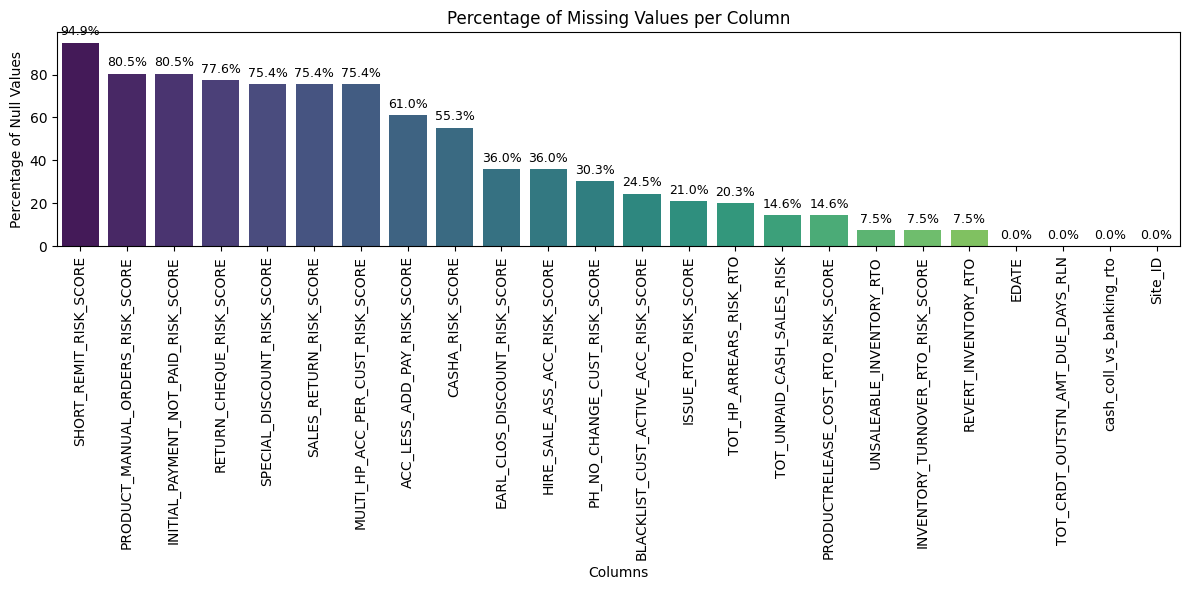

In [10]:
df_kpi_score['EDATE'] = pd.to_datetime(df_kpi_score['EDATE'])
null_df_kpi_score = pd.DataFrame(df_kpi_score.isnull().sum(),columns=['Null_Count'])
null_df_kpi_score['Null_Count'] = (null_df_kpi_score['Null_Count'] / df_kpi_score.shape[0])*100
null_df_kpi_score=null_df_kpi_score.sort_values(by='Null_Count',ascending=False)
# null_df_kpi_score.head(null_df_kpi_score.shape[0])

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=null_df_kpi_score.index,
    y=null_df_kpi_score['Null_Count'],
    palette='viridis'
)
plt.xticks(rotation=90)
plt.ylabel('Percentage of Null Values')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values per Column')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In [11]:
drop_columns = null_df_kpi_score[null_df_kpi_score['Null_Count']>25].index
print(drop_columns)

df_kpi_score.drop(drop_columns,axis=1,inplace=True)
df_kpi_score.head()

Index(['SHORT_REMIT_RISK_SCORE', 'PRODUCT_MANUAL_ORDERS_RISK_SCORE',
       'INITIAL_PAYMENT_NOT_PAID_RISK_SCORE', 'RETURN_CHEQUE_RISK_SCORE',
       'SPECIAL_DISCOUNT_RISK_SCORE', 'SALES_RETURN_RISK_SCORE',
       'MULTI_HP_ACC_PER_CUST_RISK_SCORE', 'ACC_LESS_ADD_PAY_RISK_SCORE',
       'CASHA_RISK_SCORE', 'EARL_CLOS_DISCOUNT_RISK_SCORE',
       'HIRE_SALE_ASS_ACC_RISK_SCORE', 'PH_NO_CHANGE_CUST_RISK_SCORE'],
      dtype='object')


,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,ISSUE_RTO_RISK_SCORE,cash_coll_vs_banking_rto,UNSALEABLE_INVENTORY_RTO,REVERT_INVENTORY_RTO,TOT_UNPAID_CASH_SALES_RISK,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.0,0.0,0.043791,0.047997,0.000000,0.018022,0.0,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.0,0.0,0.016666,0.026522,0.047185,0.047599,0.0,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.0,0.0,0.005226,0.037853,0.000000,0.013334,0.0,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.0,0.0,0.019839,0.092460,0.000000,0.084018,0.0,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.0,0.0,0.001064,0.046433,0.102690,0.025874,0.0,S478


In [12]:
df_kpi_score.describe()

,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,ISSUE_RTO_RISK_SCORE,cash_coll_vs_banking_rto,UNSALEABLE_INVENTORY_RTO,REVERT_INVENTORY_RTO,TOT_UNPAID_CASH_SALES_RISK,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN
count,58013,53635.000000,49527.000000,43775.000000,45834.000000,58013.000000,53635.000000,53635.000000,49527.000000,4.624500e+04,58013.000000
mean,2025-09-15 11:58:23.938772224,0.612759,0.498328,0.022969,0.003376,0.380537,0.024905,0.086684,0.028091,2.986611e-02,0.032480
min,2025-07-04 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,2025-08-09 00:00:00,0.442154,0.346552,0.000000,0.000000,0.000000,0.002199,0.018424,0.000000,7.584085e-07,0.000000
50%,2025-09-16 00:00:00,0.682829,0.500000,0.004145,0.000000,0.412722,0.006570,0.042325,0.000000,1.067325e-02,0.000000
75%,2025-10-22 00:00:00,0.837366,0.761060,0.013486,0.000000,0.691212,0.013853,0.090245,0.012189,3.963398e-02,0.000000
max,2025-11-28 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,0.999923,0.725785,1.000000,1.000000e+00,1.000000
std,NaN,0.268678,0.301597,0.069870,0.051356,0.344852,0.109364,0.113509,0.082066,6.496344e-02,0.105806


In [13]:
df_kpi_score.columns

Index(['EDATE', 'INVENTORY_TURNOVER_RTO_RISK_SCORE',
       'PRODUCTRELEASE_COST_RTO_RISK_SCORE',
       'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE', 'ISSUE_RTO_RISK_SCORE',
       'cash_coll_vs_banking_rto', 'UNSALEABLE_INVENTORY_RTO',
       'REVERT_INVENTORY_RTO', 'TOT_UNPAID_CASH_SALES_RISK',
       'TOT_HP_ARREARS_RISK_RTO', 'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN',
       'Site_ID'],
      dtype='object')

### Buid Features

In [ ]:
df_kpi_score.head()

,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,ISSUE_RTO_RISK_SCORE,cash_coll_vs_banking_rto,UNSALEABLE_INVENTORY_RTO,REVERT_INVENTORY_RTO,TOT_UNPAID_CASH_SALES_RISK,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.0,0.0,0.043791,0.047997,0.000000,0.018022,0.0,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.0,0.0,0.016666,0.026522,0.047185,0.047599,0.0,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.0,0.0,0.005226,0.037853,0.000000,0.013334,0.0,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.0,0.0,0.019839,0.092460,0.000000,0.084018,0.0,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.0,0.0,0.001064,0.046433,0.102690,0.025874,0.0,S478


In [ ]:
df_audit_grade.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116 entries, 0 to 407
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Site_ID             116 non-null    object        
 1   Shop Grade          116 non-null    object        
 2   Current Audit Date  116 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 3.6+ KB


In [14]:
feature_df = pd.DataFrame()
sites = df_dim_store['Site_ID'].unique()

for site in sites:
    try:
        audit_date = df_audit_grade[df_audit_grade['Site_ID']==site]['Current Audit Date'].dt.date.values[0]
        audit_grade = df_audit_grade[df_audit_grade['Site_ID']==site]['Shop Grade'].values[0]
    except:
        audit_date = df_kpi_score['EDATE'].max().date()
        audit_grade = None

    sub_score = df_kpi_score[(df_kpi_score ['Site_ID']==site) & (df_kpi_score ['EDATE'].dt.date<=audit_date)]
    sub_score = sub_score.sort_values(by='EDATE',ascending=False)
    sub_score.reset_index(drop=True,inplace=True)

    if sub_score.shape[0]<30:
        print('Skipping No 30 records',site,audit_date,audit_grade)
        continue
    else:
        print(site,audit_date,audit_grade)

    for i in range(0,30):

        rundate = sub_score.loc[i,'EDATE'] if sub_score.shape[0]>0 else None

        if rundate is None:
            print('Rundate is None',site)
            break

        data_dict = {'branch': site,
                    'grade': audit_grade,
                    'day': i+1,
                    'rundate':rundate,
                    'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE':sub_score.loc[i,'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE'],
                    'INVENTORY_TURNOVER_RTO_RISK_SCORE':sub_score.loc[i,'INVENTORY_TURNOVER_RTO_RISK_SCORE'],
                    'PRODUCTRELEASE_COST_RTO_RISK_SCORE':sub_score.loc[i,'PRODUCTRELEASE_COST_RTO_RISK_SCORE'],
                    'ISSUE_RTO_RISK_SCORE':sub_score.loc[i,'ISSUE_RTO_RISK_SCORE'],
                    'cash_coll_vs_banking_rto':sub_score.loc[i,'cash_coll_vs_banking_rto'],
                    'UNSALEABLE_INVENTORY_RTO':sub_score.loc[i,'UNSALEABLE_INVENTORY_RTO'],
                    'REVERT_INVENTORY_RTO':sub_score.loc[i,'REVERT_INVENTORY_RTO'],
                    'TOT_UNPAID_CASH_SALES_RISK':sub_score.loc[i,'TOT_UNPAID_CASH_SALES_RISK'],
                    'TOT_HP_ARREARS_RISK_RTO':sub_score.loc[i,'TOT_HP_ARREARS_RISK_RTO'],
                    'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN':sub_score.loc[i,'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN']
                    }
        feature_df = pd.concat([feature_df, pd.DataFrame([data_dict])],axis=0)

print('feature_df.shape',feature_df.shape)
print_table(feature_df.head())

S001 2025-09-11 B
S002 2025-11-28 None
S003 2025-11-28 None
S004 2025-11-28 None
S005 2025-11-28 None
S006 2025-11-28 None
S008 2025-11-28 None
S009 2025-11-28 None
S011 2025-11-28 None
S012 2025-09-15 A
S013 2025-11-28 None
S014 2025-11-28 None
S015 2025-11-28 None
S016 2025-11-28 None
S017 2025-09-10 A
S019 2025-11-28 None
S020 2025-09-09 B
S021 2025-11-28 None
S022 2025-11-28 None
S023 2025-09-17 A
S024 2025-10-07 A
S025 2025-11-28 None
S026 2025-11-28 None
S027 2025-09-24 B
S028 2025-11-28 None
S029 2025-11-28 None
S030 2025-11-28 None
S031 2025-11-28 None
S032 2025-11-28 None
S033 2025-08-25 A
S034 2025-09-09 A
S035 2025-09-11 A
S036 2025-11-28 None
S037 2025-10-20 A
S039 2025-09-11 B
S040 2025-10-15 B
S041 2025-09-09 B
S042 2025-11-28 None
S043 2025-11-28 None
S044 2025-11-28 None
S045 2025-11-28 None
S046 2025-11-28 None
S047 2025-11-28 None
S048 2025-11-28 None
S049 2025-11-28 None
S050 2025-11-28 None
S051 2025-11-28 None
S052 2025-11-28 None
S053 2025-11-28 None
S054 2025-11-

#### Prepare Training Data

In [15]:
def build_input_matrix(df,feature_cols):
    times = df['day'].values.reshape(-1, 1)
    feats = df[feature_cols].values
    X = np.hstack([times, feats])
    return X.astype(np.float64)

graded_df = feature_df.dropna(subset=['grade']).copy()
graded_df.fillna(0, inplace=True)

ungraded_df = feature_df[feature_df['grade'].isna()].copy()
ungraded_df.fillna(0, inplace=True)

print(f"Graded branches: {graded_df['branch'].nunique()} (out of {feature_df['branch'].nunique()})")
print(f"Total observations: {len(feature_df)}")

# Encode grades
le = LabelEncoder()
y_all = le.fit_transform(feature_df['grade'].fillna('Unknown'))
y_graded = le.transform(graded_df['grade'])
grades = le.classes_[:-1]  # exclude 'Unknown'
print("Grades:", grades)

feature_cols = list(feature_df.drop(columns=['branch','grade','day','rundate']).columns)

X_train = build_input_matrix(graded_df,feature_cols)   # (N_train, 4): [time, f1, f2, f3]
Y_train = y_graded.reshape(-1, 1)         # (N_train, 1)

# Scale time and features separately
scaler_time = StandardScaler()
scaler_feats = StandardScaler()

X_train[:, 0] = scaler_time.fit_transform(X_train[:, 0].reshape(-1, 1)).flatten()
X_train[:, 1:] = scaler_feats.fit_transform(X_train[:, 1:])

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

Graded branches: 116 (out of 411)
Total observations: 12330
Grades: ['A' 'B' 'C' 'C-' 'D' 'D-']
X_train shape: (3480, 11)
Y_train shape: (3480, 1)


#### Buid Bayesian Model

In [24]:
kernel = gpflow.kernels.RBF() * gpflow.kernels.Linear()  # multiplicative interaction
num_inducing = min(100, len(X_train) )
kmeans = KMeans(n_clusters=num_inducing, random_state=0).fit(X_train)
Z = kmeans.cluster_centers_
model = gpflow.models.SVGP(
    kernel=kernel,
    likelihood=gpflow.likelihoods.MultiClass(num_classes=len(grades)),
    inducing_variable=Z,
    num_latent_gps=len(grades),  # one latent per class
    whiten=True
)
gpflow.set_trainable(model.q_mu, True)
gpflow.set_trainable(model.q_sqrt, True)

def objective_closure():
    return -model.elbo((X_train, Y_train))

adam = tf.optimizers.Adam(learning_rate=0.01)

for step in trange(2000, desc="Adam training"):
    with tf.GradientTape() as tape:
        loss = objective_closure()
    grads = tape.gradient(loss, model.trainable_variables)
    adam.apply_gradients(zip(grads, model.trainable_variables))

    if step % 50 == 0:
        tqdm.write(f"Step {step} | Loss: {loss.numpy():.4f}")

opt = gpflow.optimizers.Scipy()
opt.minimize(objective_closure, model.trainable_variables, options=dict(maxiter=2000))

model = model
print("Training complete.")

Adam training:   0%|          | 1/2000 [00:00<18:20,  1.82it/s]

Step 0 | Loss: 24700.5265


Adam training:   3%|▎         | 51/2000 [00:29<17:01,  1.91it/s]

Step 50 | Loss: 17288.4907


Adam training:   5%|▌         | 101/2000 [00:58<12:55,  2.45it/s]

...

Step 1900 | Loss: 6462.8450


Adam training:  98%|█████████▊| 1951/2000 [15:49<00:28,  1.73it/s]

Step 1950 | Loss: 6414.0434


Adam training: 100%|██████████| 2000/2000 [16:10<00:00,  2.06it/s]


Training complete.


In [25]:
def predictive_entropy(probs):
    return -np.sum(probs * np.log(probs + 1e-9))

def get_prediction_with_uncertainty(df, model):
    results = []

    for branch in df['branch'].unique():
        branch_df = df[df['branch'] == branch]

        X_test = build_input_matrix(branch_df, feature_cols)

        # Apply same scaling as training
        X_test[:, 0] = scaler_time.transform(X_test[:, 0].reshape(-1, 1)).flatten()
        X_test[:, 1:] = scaler_feats.transform(X_test[:, 1:])

        # Predict class probabilities for each time step
        prob_mean, _ = model.predict_y(X_test)
        prob_time = prob_mean.numpy()

        # Aggregate over time
        prob_branch = prob_time.mean(axis=0)

        entropy = predictive_entropy(prob_branch)
        pred_grade = grades[np.argmax(prob_branch)]

        results.append({
            "branch": branch,
            "predicted_grade": pred_grade,
            "entropy": entropy,
            "max_prob": np.max(prob_branch)
        })

    return pd.DataFrame(results)

uncertainty_df = get_prediction_with_uncertainty(graded_df, model)

# True grades
true_df = graded_df[['branch', 'grade']].drop_duplicates()

uncertainty_df = uncertainty_df.merge(true_df, on='branch', how='left')

# Correct / incorrect flag
uncertainty_df['correct'] = (
    uncertainty_df['predicted_grade'] == uncertainty_df['grade']
)


In [26]:
print("Mean entropy (Correct predictions):",
      uncertainty_df[uncertainty_df['correct']]['entropy'].mean())

print("Mean entropy (Incorrect predictions):",
      uncertainty_df[~uncertainty_df['correct']]['entropy'].mean())


Mean entropy (Correct predictions): 0.16837185653739573
Mean entropy (Incorrect predictions): 0.356203168584159


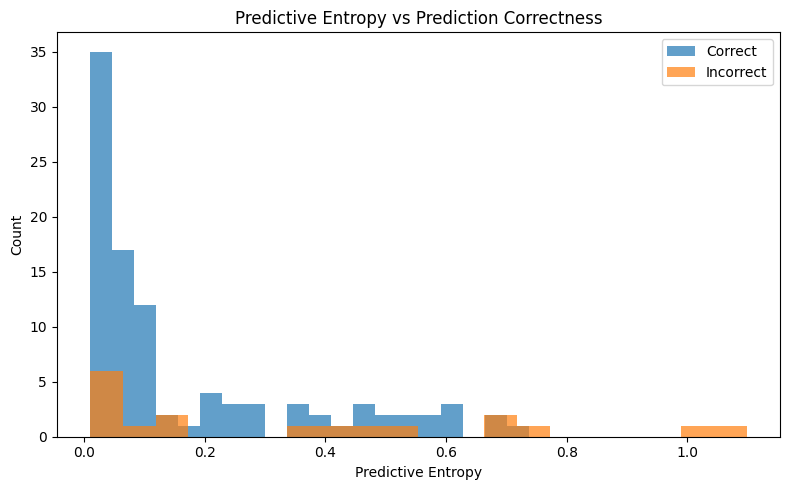

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(
    uncertainty_df[uncertainty_df['correct']]['entropy'],
    bins=20,
    alpha=0.7,
    label='Correct'
)
plt.hist(
    uncertainty_df[~uncertainty_df['correct']]['entropy'],
    bins=20,
    alpha=0.7,
    label='Incorrect'
)

plt.xlabel("Predictive Entropy")
plt.ylabel("Count")
plt.title("Predictive Entropy vs Prediction Correctness")
plt.legend()
plt.tight_layout()
plt.show()


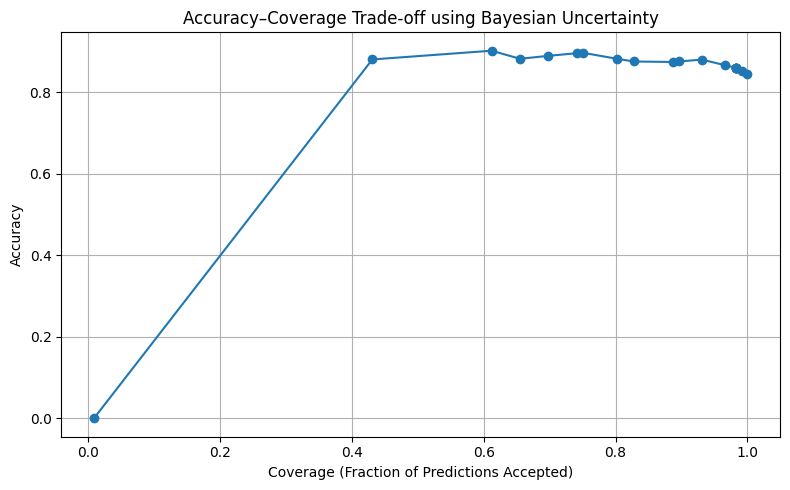

In [29]:
thresholds = np.linspace(
    uncertainty_df['entropy'].min(),
    uncertainty_df['entropy'].max(),
    20
)

coverage = []
accuracy = []

for t in thresholds:
    accepted = uncertainty_df[uncertainty_df['entropy'] <= t]

    if len(accepted) == 0:
        continue

    acc = accuracy_score(
        accepted['grade'],
        accepted['predicted_grade']
    )

    coverage.append(len(accepted) / len(uncertainty_df))
    accuracy.append(acc)


plt.figure(figsize=(8, 5))
plt.plot(coverage, accuracy, marker='o')
plt.xlabel("Coverage (Fraction of Predictions Accepted)")
plt.ylabel("Accuracy")
plt.title("Accuracy–Coverage Trade-off using Bayesian Uncertainty")
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
summary_df = pd.DataFrame({
    "coverage": coverage,
    "accuracy": accuracy
})

print(summary_df.head())


   coverage  accuracy
0  0.008621  0.000000
1  0.431034  0.880000
2  0.612069  0.901408
3  0.655172  0.881579
4  0.698276  0.888889


In [ ]:
*

#### Inference

In [ ]:
def get_prediction(df):
    results = []

    for branch in df['branch'].unique():
        branch_df = df[df['branch'] == branch]
        X_test = build_input_matrix(branch_df,feature_cols)

        # Scale using training scalers
        X_test[:, 0] = scaler_time.transform(X_test[:, 0].reshape(-1, 1)).flatten()
        X_test[:, 1:] = scaler_feats.transform(X_test[:, 1:])

        # Predict mean probabilities per time point
        prob_mean, prob_var = model.predict_y(X_test)
        prob_per_point = prob_mean.numpy()  # Already softmaxed probabilities for each class

        # Aggregate over time: mean probability per grade
        prob_branch = prob_per_point.mean(axis=0)
        pred_grade = grades[np.argmax(prob_branch)]

        # Store
        row = {'branch': branch, 'predicted_grade': pred_grade}
        for i, g in enumerate(grades):
            row[f'prob_{g}'] = prob_branch[i]
        results.append(row)

    results_df = pd.DataFrame(results)
    print_table(results_df.head())
    return results_df

ungraded_df_result = get_prediction(ungraded_df)
print(ungraded_df_result.shape)
graded_df_result = get_prediction(graded_df)
print(graded_df_result.shape)

+--------+-----------------+----------------------+------------------------+------------------------+------------------------+------------------------+-----------------------+
| branch | predicted_grade |        prob_A        |         prob_B         |         prob_C         |        prob_C-         |         prob_D         |        prob_D-        |
+--------+-----------------+----------------------+------------------------+------------------------+------------------------+------------------------+-----------------------+
|  S002  |        C        | 0.01565042214323591  | 0.00020000014752214073 |   0.982194390743675    | 0.00021227547038342155 | 0.0014913482753687258  | 0.0002475789773295885 |
|  S003  |        A        |  0.9966807149229825  | 0.00020048857942246958 |  0.000200000000483083  | 0.00020065584447950647 |  0.002483711158089092  | 0.0002351213581527782 |
|  S004  |        B        | 0.022212374740831767 |   0.9104812225701617   |  0.041908154076085294  |  0.008240007488053

#### Evaluate Result

In [ ]:
def evaluate_train_result(results_df):
    site_acc = graded_df[['branch','grade']]
    site_acc.drop_duplicates(inplace=True)
    print(site_acc.shape)
    print('graded_df value count\n',site_acc['grade'].value_counts())

    print('results_df value count\n',results_df['predicted_grade'].value_counts())

    site_acc = site_acc.merge(results_df[['branch', 'predicted_grade']], on='branch', how='left')
    print(classification_report(site_acc['grade'], site_acc['predicted_grade']))

evaluate_train_result(graded_df_result)

print('ungraded_df_result.shape',ungraded_df_result.shape)
print('graded_df_result.shape',graded_df_result.shape)

(116, 2)
graded_df value count
 grade
A     71
B     31
C      6
D      4
C-     3
D-     1
Name: count, dtype: int64
results_df value count
 predicted_grade
A     85
B     23
C      4
D      3
C-     1
Name: count, dtype: int64
              precision    recall  f1-score   support

           A       0.82      0.99      0.90        71
           B       0.87      0.65      0.74        31
           C       1.00      0.67      0.80         6
          C-       1.00      0.33      0.50         3
           D       1.00      0.75      0.86         4
          D-       0.00      0.00      0.00         1

    accuracy                           0.84       116
   macro avg       0.78      0.56      0.63       116
weighted avg       0.85      0.84      0.83       116

ungraded_df_result.shape (295, 8)
graded_df_result.shape (116, 8)


In [ ]:
df_dim_store.head()

,Site_ID
0,S001
1,S002
2,S003
3,S004
4,S005


In [ ]:
ungraded_df_result.rename(columns={'branch':'Site_ID'},inplace=True)
df_final = df_dim_store.merge(ungraded_df_result[['Site_ID','predicted_grade']],on='Site_ID',how='left')
df_final['Rundate'] = datetime.today()

df_audit_grade.rename(columns={'Shop Code':'Site_ID',
                                    'Current Audit Date':'Last_Audit_Date',
                                    'Shop Grade':'Last_Audit_Grade'
                                    },inplace=True)
df_final = df_final.merge(df_audit_grade[['Site_ID','Last_Audit_Grade','Last_Audit_Date']],on='Site_ID',how='left')
print('END OF THE PIPELINE..................')

END OF THE PIPELINE..................


In [ ]:
print(df_final['Site_ID'].nunique())
df_final.isnull().sum()

413


,0
Site_ID,0
predicted_grade,118
Rundate,0
Last_Audit_Grade,297
Last_Audit_Date,297


In [ ]:
print_table(df_final.sample(50))

+---------+-----------------+----------------------------+------------------+---------------------+
| Site_ID | predicted_grade |          Rundate           | Last_Audit_Grade |   Last_Audit_Date   |
+---------+-----------------+----------------------------+------------------+---------------------+
|   S400  |       nan       | 2025-12-29 15:23:28.293752 |        B         | 2025-10-09 00:00:00 |
|   S342  |       nan       | 2025-12-29 15:23:28.293752 |        A         | 2025-09-19 00:00:00 |
|   S467  |       nan       | 2025-12-29 15:23:28.293752 |        B         | 2025-10-21 00:00:00 |
|   S207  |       nan       | 2025-12-29 15:23:28.293752 |        A         | 2025-09-08 00:00:00 |
|   S315  |        A        | 2025-12-29 15:23:28.293752 |       nan        |         NaT         |
|   S433  |        B        | 2025-12-29 15:23:28.293752 |       nan        |         NaT         |
|   S044  |        B        | 2025-12-29 15:23:28.293752 |       nan        |         NaT         |
